# DDPM 正向扩散公式详解

## 核心公式

$$q(x_t \mid x_{t-1}) := \mathcal{N}\left(x_t;\; \sqrt{1-\beta_t}\, x_{t-1},\; \beta_t \mathbf{I}\right)$$

这个公式来自论文 **DDPM (Denoising Diffusion Probabilistic Models, Ho et al. 2020)**，描述了**正向扩散过程（forward diffusion process）**的单步转移。

用简单直接的语言解释：
- $q(x_t \mid x_{t-1})$：正向条件分布，描述在已知 $x_{t-1}$（t-1时刻图像的具体值）的条件下，t时刻图像 $x_t$ 的概率分布
- $\mathcal{N}(x;\, \mu, \Sigma)$：多元正态分布，$\mu$ 是均值向量，$\Sigma$ 是协方差矩阵
- $\sqrt{1-\beta_t}\, x_{t-1}$：t-1时刻图像 $x_{t-1}$ 的均值，用于计算 t时刻图像 $x_t$ 的均值
    - 这里的 $\beta_t$ 是一个时间步 t 的参数，用于控制扩散过程的强度，常见设定方式比如：
        - 线性schedule：$\beta_t = linear(\beta_{start}, \beta_{end}, t)$，其中 $\beta_{start}$ 是 $\beta_t$ 的初始值，$\beta_{end}$ 是 $\beta_t$ 的最终值，$t$ 是时间步，T=1000
    - 比如$\beta_t$值为0.1，则$\sqrt{1-0.1} = 0.95$，相当于对t-1时刻的像素值缩小5%


---

## 1. 符号含义拆解

| 符号 | 含义 |
|------|------|
| $x_t$ | 第 $t$ 步的带噪图像（随机变量）|
| $x_{t-1}$ | 第 $t-1$ 步的图像（已知条件）|
| $q(x_t \mid x_{t-1})$ | 从 $x_{t-1}$ 出发，生成 $x_t$ 的条件概率分布 |
| $\beta_t$ | 第 $t$ 步的**噪声调度（noise schedule）**，$\beta_t \in (0, 1)$，随 $t$ 增大而增大 |
| $\mathcal{N}(x; \mu, \Sigma)$ | 均值为 $\mu$、方差为 $\Sigma$ 的高斯分布 |
| $\mathbf{I}$ | 单位矩阵（各维度独立、方差相同）|

这个公式说的是：**已知第 $t-1$ 步的图像 $x_{t-1}$，第 $t$ 步的图像 $x_t$ 服从均值为 $\sqrt{1-\beta_t}\, x_{t-1}$、方差为 $\beta_t \mathbf{I}$ 的高斯分布。**

---

## 2. 采样过程的直觉理解

根据高斯分布的采样公式，$x_t$ 可以这样得到：

$$x_t = \sqrt{1-\beta_t}\, x_{t-1} + \sqrt{\beta_t}\, \epsilon, \quad \epsilon \sim \mathcal{N}(0, \mathbf{I})$$

**直觉分解：**

- **第一项** $\sqrt{1-\beta_t}\, x_{t-1}$：对上一步图像进行轻微缩放（系数略小于 1），信号被压缩一点点
- **第二项** $\sqrt{\beta_t}\, \epsilon$：叠加一个小量高斯噪声

两项合起来：每一步都让图像**稍微向纯噪声靠近一点**，信号逐渐消融。

> 关键约束：两个系数的平方和为 1，即 $(1-\beta_t) + \beta_t = 1$，这保证了**方差守恒**，使得整个链条的统计性质可控。

---

## 3. 为什么要用 $\sqrt{1-\beta_t}$ 而不是 $(1-\beta_t)$？

**验证方差守恒：**

假设 $x_{t-1}$ 的方差为 1（标准化后）：

$$\text{Var}(x_t) = (\sqrt{1-\beta_t})^2 \cdot \text{Var}(x_{t-1}) + (\sqrt{\beta_t})^2 \cdot \text{Var}(\epsilon)$$

$$= (1-\beta_t) \cdot 1 + \beta_t \cdot 1 = 1$$

方差保持为 1！这正是使用 $\sqrt{1-\beta_t}$ 的原因：让每一步加噪后的分布**方差保持不变**，整个扩散链条在统计上是稳定的。

In [ ]:
import torch
import matplotlib.pyplot as plt

# 验证：单步加噪的方差守恒
torch.manual_seed(42)
beta = 0.1  # 某一步的 beta_t
x_prev = torch.randn(100000)  # x_{t-1} ~ N(0,1), 方差=1

eps = torch.randn(100000)     # 噪声 epsilon ~ N(0,1)
x_curr = (1 - beta)**0.5 * x_prev + beta**0.5 * eps  # 采样 x_t

print(f'x_{{t-1}} 方差: {x_prev.var():.4f}  (期望值 1.0)')
print(f'x_t     方差: {x_curr.var():.4f}  (期望值 1.0)')
print(f'方差守恒: {abs(x_curr.var().item() - 1.0) < 0.01}')

---

## 4. $T$ 步之后的闭合形式（Closed-form）

DDPM 最漂亮的性质：**无需逐步迭代，可以直接从 $x_0$ 采样任意时刻 $x_t$！**

定义累积系数 $\bar{\alpha}_t$：

$$\bar{\alpha}_t = \prod_{s=1}^{t} (1 - \beta_s)$$

则：

$$q(x_t \mid x_0) = \mathcal{N}\left(x_t;\; \sqrt{\bar{\alpha}_t}\, x_0,\; (1 - \bar{\alpha}_t) \mathbf{I}\right)$$

采样形式：

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon, \quad \epsilon \sim \mathcal{N}(0, \mathbf{I})$$

**直觉：**

- 当 $t=0$：$\bar{\alpha}_0 = 1$，$x_0 = x_0$（无噪声，纯原始图像）
- 当 $t=T$：$\bar{\alpha}_T \approx 0$，$x_T \approx \epsilon$（纯高斯噪声）
- 中间：$x_t$ 是原始图像和噪声的插值，$t$ 越大，噪声越多

In [11]:
import torch
import matplotlib.pyplot as plt

T = 1000
# linear noise schedule: beta increases from 1e-4 to 0.02
betas = torch.linspace(1e-4, 0.02, T)
betas[:5]


tensor([1.0000e-04, 1.1992e-04, 1.3984e-04, 1.5976e-04, 1.7968e-04])

In [13]:
alphas = 1 - betas
alphas[:5]


tensor([0.9999, 0.9999, 0.9999, 0.9998, 0.9998])

In [14]:
alpha_bars = torch.cumprod(alphas, dim=0)  # alpha_bar_t
alpha_bars[:5]


tensor([0.9999, 0.9998, 0.9996, 0.9995, 0.9993])

In [15]:

ts = torch.arange(T)
ts[:5]


tensor([0, 1, 2, 3, 4])

In [17]:
signal_coeff = alpha_bars.sqrt()           # signal coeff: sqrt(alpha_bar_t)
signal_coeff[:5]


tensor([0.9999, 0.9999, 0.9998, 0.9997, 0.9997])

In [19]:
noise_coeff  = (1 - alpha_bars).sqrt()     # noise coeff:  sqrt(1 - alpha_bar_t)
noise_coeff[:5]


tensor([0.0100, 0.0148, 0.0190, 0.0228, 0.0264])

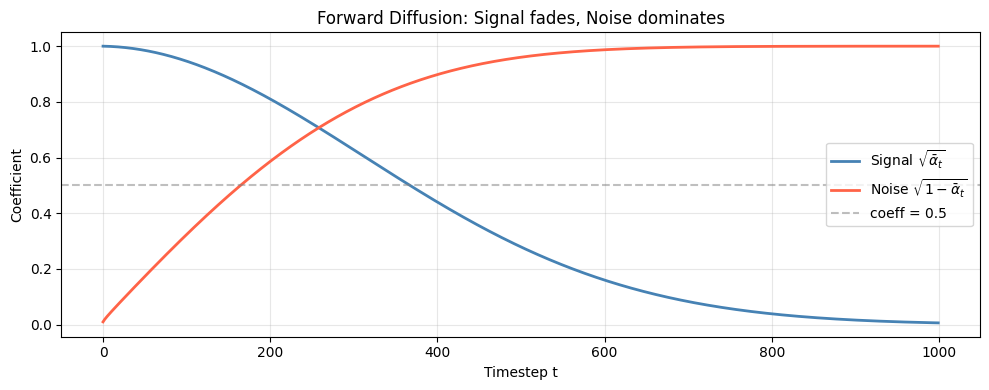

Signal = Noise at timestep t = 258 (out of 1000)


In [20]:

plt.figure(figsize=(10, 4))
plt.plot(ts, signal_coeff, label=r'Signal $\sqrt{\bar{\alpha}_t}$', color='steelblue', linewidth=2)
plt.plot(ts, noise_coeff,  label=r'Noise $\sqrt{1-\bar{\alpha}_t}$', color='tomato', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='coeff = 0.5')
plt.xlabel('Timestep t')
plt.ylabel('Coefficient')
plt.title('Forward Diffusion: Signal fades, Noise dominates')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cross = (signal_coeff - noise_coeff).abs().argmin().item()
print(f'Signal = Noise at timestep t = {cross} (out of {T})')

In [2]:
# 展示不同 t 下 x_t 的变化
torch.manual_seed(0)
x0  = torch.tensor([1.0])
eps = torch.randn(1)

show_steps = [0, 100, 300, 500, 700, 900, 999]
print(f"{'t':>5} | {'x_t':>10} | {'信号系数':>10} | {'噪声系数':>10}")
print('-' * 48)
for t in show_steps:
    ab = alpha_bars[t]
    xt = ab.sqrt() * x0 + (1 - ab).sqrt() * eps
    print(f"{t:>5} | {xt.item():>10.4f} | {ab.sqrt().item():>10.4f} | {(1-ab).sqrt().item():>10.4f}")

    t |        x_t |       信号系数 |       噪声系数
------------------------------------------------
    0 |     1.0154 |     0.9999 |     0.0100
  100 |     1.4451 |     0.9461 |     0.3238
  300 |     1.8273 |     0.6277 |     0.7785
  500 |     1.7588 |     0.2789 |     0.9603
  700 |     1.6186 |     0.0829 |     0.9966
  900 |     1.5572 |     0.0164 |     0.9999
  999 |     1.5473 |     0.0064 |     1.0000


---

## 5. 为什么整条链是马尔可夫链？

公式 $q(x_t \mid x_{t-1})$ 只依赖 $x_{t-1}$，与更早的 $x_0, x_1, \ldots, x_{t-2}$ **无关**。

因此整个正向过程是一条**马尔可夫链（Markov Chain）**：

$$q(x_{1:T} \mid x_0) = \prod_{t=1}^{T} q(x_t \mid x_{t-1})$$

这使得正向过程的联合概率可以**分解为每步转移概率的乘积**，计算上非常便利。

---

## 6. 与反向过程的关系

DDPM 训练的目标是学习**反向过程**：

$$p_\theta(x_{t-1} \mid x_t) = \mathcal{N}\left(x_{t-1};\; \mu_\theta(x_t, t),\; \Sigma_\theta(x_t, t)\right)$$

| | 正向过程 $q$ | 反向过程 $p_\theta$ |
|--|--|--|
| 方向 | $x_0 \to x_T$（加噪）| $x_T \to x_0$（去噪）|
| 是否已知 | 完全确定（由 $\beta_t$ 决定）| 需要神经网络学习 |
| 参数 | $\beta_t$（超参数）| $\theta$（网络权重）|

正向过程的闭合形式（第4节）正是 DDPM 训练的关键：

1. 随机采样时间步 $t$
2. 用 $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon$ **一步**生成带噪图像
3. 让 UNet **预测噪声 $\epsilon$**，最小化预测误差

$$\mathcal{L} = \mathbb{E}_{t, x_0, \epsilon}\left[\|\epsilon - \epsilon_\theta(x_t, t)\|^2\right]$$

---

## 7. 总结

$$q(x_t \mid x_{t-1}) := \mathcal{N}\left(x_t;\; \sqrt{1-\beta_t}\, x_{t-1},\; \beta_t \mathbf{I}\right)$$

| # | 关键点 |
|---|--------|
| 1 | **每步加噪**：将上一帧缩小 $\sqrt{1-\beta_t}$ 倍，再叠加标准差为 $\sqrt{\beta_t}$ 的高斯噪声 |
| 2 | **方差守恒**：$(1-\beta_t) + \beta_t = 1$，保证每步后的方差不变 |
| 3 | **马尔可夫性**：当前步只依赖前一步，整条链可以分解 |
| 4 | **闭合形式**：可以直接从 $x_0$ 跳到任意 $x_t$，使训练高效 |
| 5 | **训练目标**：正向过程提供无限带噪样本，网络学习将噪声还原 |